# Supplemental: Matplotlib & Seaborn — a working syntax reference

**CS1090A / AC209A — Module 1**

The visualization lecture covers *concepts* — what makes a plot honest, legible,
and worth a reader's time. This notebook is the *syntax* companion: the handful of
plotting patterns that cover ~95% of the EDA you'll do in HW1 (Q5, Q8) and beyond.

Treat it as a reference: skim now, come back when you need the incantation.

**The one HW1 rule to internalize:** every plot must be interpretable *without*
reading the code that made it — axis labels, a descriptive title, and a legend
when more than one thing is on the axes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()   # seaborn's default look: grid, muted palette

We'll use two small datasets that ship with seaborn: `tips` (restaurant bills)
and `penguins` (body measurements of 3 species). They download once and are
cached locally in `~/seaborn-data/`.

In [2]:
tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins").dropna()
tips.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


## 1. The anatomy: `Figure` and `Axes`

Matplotlib's mental model is two objects:

- **`Figure`** — the whole canvas (can hold several plots).
- **`Axes`** — one plot: an x-axis, a y-axis, and the stuff drawn on them.

The most reliable pattern is the **object-oriented style**: create them
explicitly with `plt.subplots()`, then call methods *on the axes*. Every plotting
library you'll meet (including seaborn and pandas' `.plot`) ultimately hands you
an `Axes`, so labeling/limits/legends always work the same way.

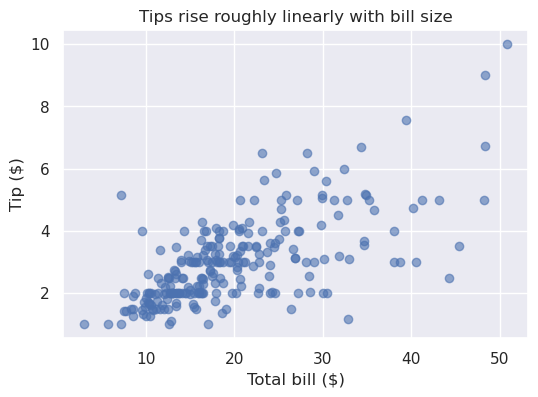

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(tips["total_bill"], tips["tip"], alpha=0.6)

# The labeling trio — do this on every plot
ax.set_xlabel("Total bill ($)")
ax.set_ylabel("Tip ($)")
ax.set_title("Tips rise roughly linearly with bill size")
plt.show()

## 2. Plotting straight from a DataFrame

Pandas objects have a `.plot` accessor that wraps matplotlib — ideal for quick
looks mid-analysis. `value_counts().plot(kind='barh')` is the single most useful
EDA one-liner: horizontal bars keep long category names readable.

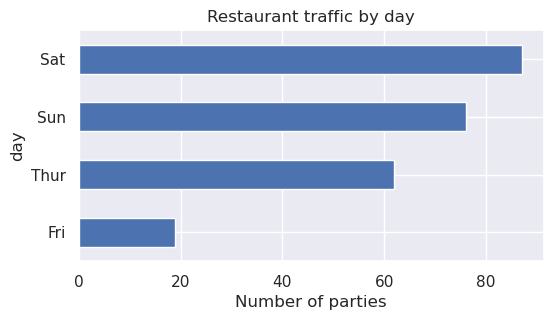

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))
tips["day"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Number of parties")
ax.set_title("Restaurant traffic by day")
plt.show()

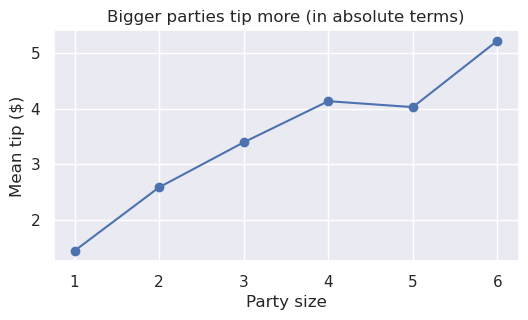

In [5]:
# .plot works on whole frames too — each numeric column becomes a line/series
fig, ax = plt.subplots(figsize=(6, 3))
tips.groupby("size")["tip"].mean().plot(marker="o", ax=ax)
ax.set_xlabel("Party size")
ax.set_ylabel("Mean tip ($)")
ax.set_title("Bigger parties tip more (in absolute terms)")
plt.show()

## 3. Seaborn's grammar: `data=`, `x=`, `y=`, `hue=`

Seaborn shines when your data is already a tidy DataFrame: you name columns
instead of passing arrays, and `hue=` adds a third variable with a legend for
free. Use seaborn for statistical plots; drop to the returned `Axes` for labels.

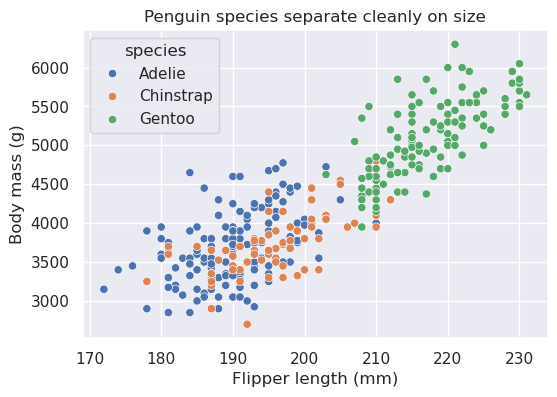

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g",
                hue="species", ax=ax)
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.set_title("Penguin species separate cleanly on size")
plt.show()

## 4. Distributions — the EDA workhorses

Choosing among them:

| Plot | Use when |
|---|---|
| `histplot` | one distribution; you care about its shape |
| `kdeplot` | smooth comparison of 2–3 overlapping distributions |
| `boxplot` | comparing many groups compactly (hides multimodality!) |
| `violinplot` | many groups, but shape matters |
| `stripplot` | few observations per group — show the actual points |

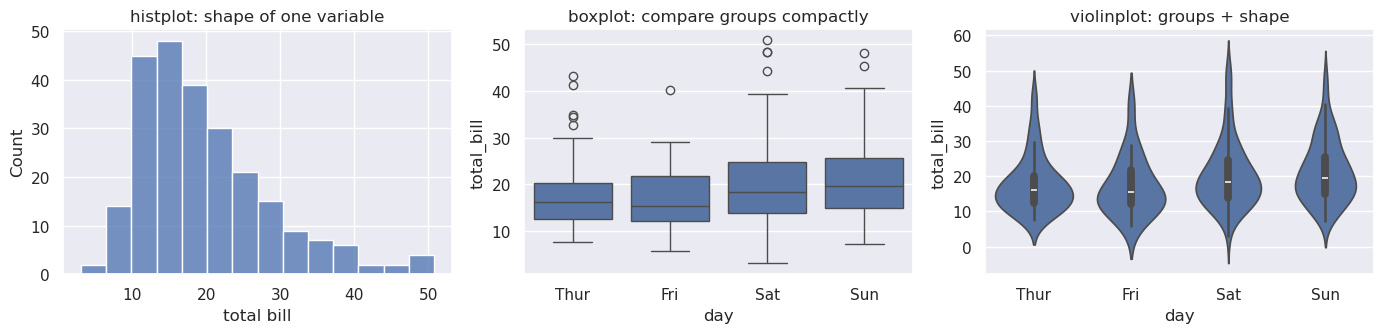

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.5))

sns.histplot(data=tips, x="total_bill", ax=axs[0])
axs[0].set_title("histplot: shape of one variable")

sns.boxplot(data=tips, x="day", y="total_bill", ax=axs[1])
axs[1].set_title("boxplot: compare groups compactly")

sns.violinplot(data=tips, x="day", y="total_bill", ax=axs[2])
axs[2].set_title("violinplot: groups + shape")

for ax in axs:
    ax.set_xlabel(ax.get_xlabel().replace("_", " "))
plt.tight_layout()
plt.show()

## 5. Subplots that share an axis

When two panels invite comparison, **share the comparison axis** so the reader's
eye can move between them honestly (HW1 Q5 asks for exactly this pattern).

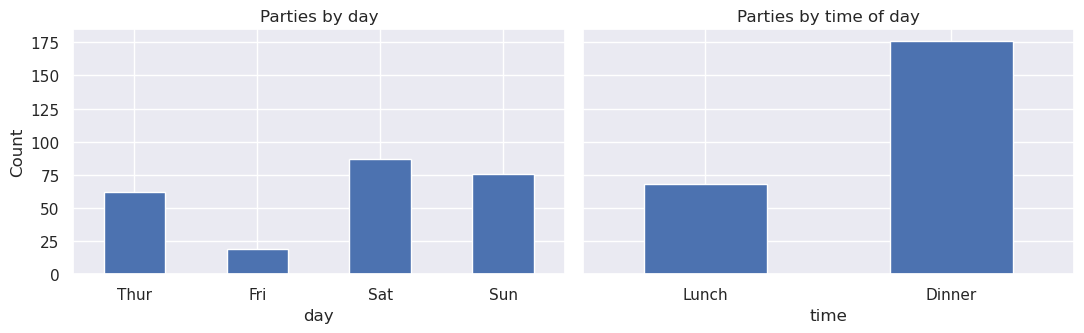

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)

tips.groupby("day", observed=True)["total_bill"].count()\
    .plot(kind="bar", ax=axs[0], rot=0)
axs[0].set_title("Parties by day")
axs[0].set_ylabel("Count")

tips.groupby("time", observed=True)["total_bill"].count()\
    .plot(kind="bar", ax=axs[1], rot=0)
axs[1].set_title("Parties by time of day")

plt.tight_layout()
plt.show()

## 6. Trends: scatter + fitted line

`sns.regplot` overlays a simple linear fit with a confidence band — useful for
"is there a relationship?" questions before you have any modeling tools.

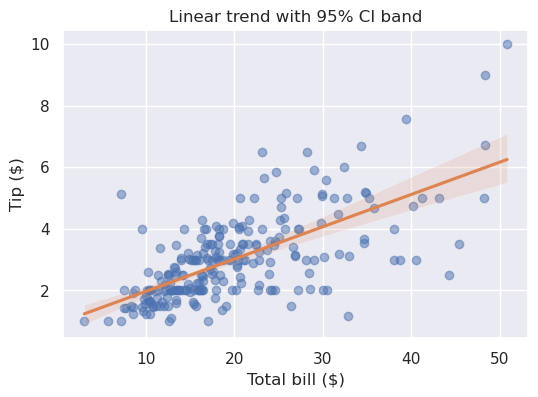

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.regplot(data=tips, x="total_bill", y="tip",
            scatter_kws={"alpha": 0.5}, line_kws={"color": "C1"}, ax=ax)
ax.set_xlabel("Total bill ($)")
ax.set_ylabel("Tip ($)")
ax.set_title("Linear trend with 95% CI band")
plt.show()

## 7. Accessibility: design for every reader

Roughly **1 in 12 men** has some color-vision deficiency — in a lecture hall of
200, that's a dozen people who can't tell your red series from your green one.
Three habits cover most of it:

1. **Use a colorblind-safe palette** — seaborn ships one.
2. **Encode redundantly** — pair color with marker shape, line style, or direct
   labels, so color is never the *only* channel carrying a distinction.
3. **Write alt text / captions** that state the finding, for screen readers and
   for anyone skimming.

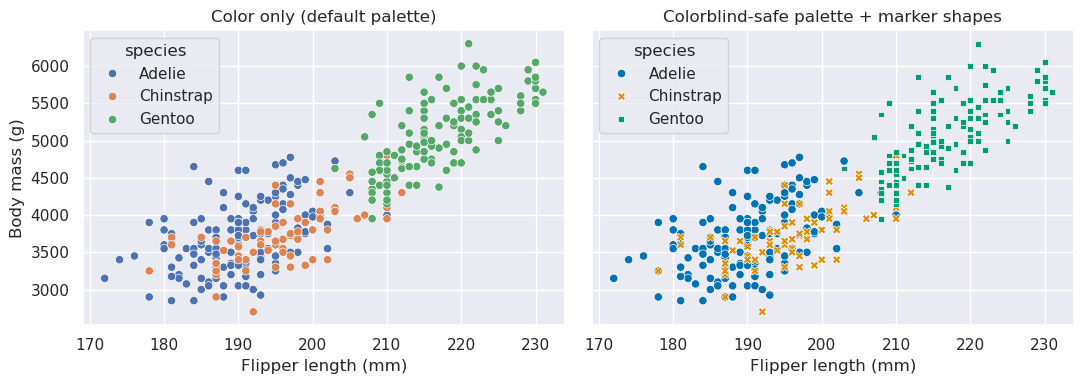

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True, sharex=True)

# Default palette + color-only encoding (left) vs colorblind-safe palette +
# redundant marker shapes (right)
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g",
                hue="species", ax=axs[0])
axs[0].set_title("Color only (default palette)")

sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g",
                hue="species", style="species",
                palette="colorblind", ax=axs[1])
axs[1].set_title("Colorblind-safe palette + marker shapes")

for ax in axs:
    ax.set_xlabel("Flipper length (mm)")
axs[0].set_ylabel("Body mass (g)")
plt.tight_layout()
plt.show()

For sequential (quantitative) color, prefer perceptually-uniform colormaps
(`viridis`, `rocket`, `mako`) over rainbow — they stay readable in grayscale
print and to color-deficient readers alike.

## 8. Saving figures

`fig.savefig` writes whatever the figure currently looks like. Use
`bbox_inches='tight'` so labels aren't clipped, and `dpi=150`+ for crisp raster
output. (Writing figures to files is another small piece of a reproducible
pipeline: your report's images regenerate from code.)

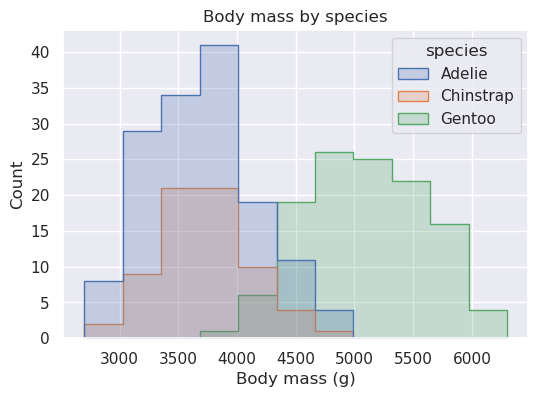

wrote figures/penguin_mass.png


In [11]:
import os
os.makedirs("figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=penguins, x="body_mass_g", hue="species", element="step", ax=ax)
ax.set_xlabel("Body mass (g)")
ax.set_title("Body mass by species")
fig.savefig("figures/penguin_mass.png", dpi=150, bbox_inches="tight")
plt.show()
print("wrote figures/penguin_mass.png")

## 9. Pre-submission checklist

For every plot in your homework:

- [ ] x- and y-axis labels, in units a reader understands
- [ ] a descriptive title (state the *finding* when you can, not just the variables)
- [ ] a legend whenever `hue=`/multiple series are in play
- [ ] readable tick labels (rotate or `barh` when names are long)
- [ ] color is never the *only* channel (colorblind-safe palette, shapes/labels)
- [ ] an interpretation in the surrounding markdown — what does the plot *mean*?

**Exercises:**
1. Recreate the §5 side-by-side panel using `tips`, but split by `smoker` instead
   of `time`. Keep the shared y-axis.
2. In §4, the Friday boxplot is based on very few parties. Overlay a `stripplot`
   on the boxplot axes to make the sample size visible. Why does this matter for
   the conclusions you'd draw?
3. Take one plot you've made in this notebook and rewrite its title to state a
   finding rather than a description.